<a href="https://colab.research.google.com/github/monishasrinivas-04/Urban-Heat-Mapping-using-YOLOv8/blob/main/Multivariate_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap xgboost wordcloud seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from scipy.sparse import hstack

from wordcloud import WordCloud

import shap

from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Dataset_5971.csv')

print(df.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset_5971.csv'

In [ ]:
print(df.info())
print(df.isnull().sum())

In [ ]:
df['LABEL']= df['LABEL'].str.lower()
label_counts = df['LABEL'].value_counts()
print(label_counts)
colors = ['lightgreen', 'red', 'orange']

plt.figure(figsize=(7,7))
plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title('Dataset Distribution')
plt.show()

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='LABEL', data=df, palette=['lightgreen','red','orange'])

plt.title('Class Distribution')
plt.show()

In [ ]:
df['char_count'] = df['TEXT'].apply(len)
df['word_count'] = df['TEXT'].apply(lambda x: len(str(x).split()))
#AVG CHAR
avg_char = df.groupby('LABEL')['char_count'].mean()
print(avg_char)
#AVG WORD
avg_word = df.groupby('LABEL')['word_count'].mean()
print(avg_word)

In [ ]:
#Visualisation
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.barplot(
    x=avg_char.index,
    y=avg_char.values,
    palette=['lightgreen','orange','red'],
    ax=axes[0]
)
axes[0].set_title('Average Character Count')

sns.barplot(
    x=avg_word.index,
    y=avg_word.values,
    palette=['lightgreen','orange','red'],
    ax=axes[1]
)
axes[1].set_title('Average Word Count')

plt.show()

In [ ]:
binary_cols = ['URL', 'EMAIL', 'PHONE']

for col in binary_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df[col] = df[col].map({
        'YES':1,
        'NO':0
    })

    # fill missing values
    df[col] = df[col].fillna(0)
df['TEXT'] = df['TEXT'].fillna('')

In [ ]:
le = LabelEncoder()
df['LABEL_ENCODED'] = le.fit_transform(df['LABEL'])

print(le.classes_)

['ham' 'smishing' 'spam']


In [ ]:
max_features=5000
max_features=300
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=300
)

X_text = vectorizer.fit_transform(df['TEXT'])

In [ ]:
X_meta = df[binary_cols].values

X = hstack([X_text, X_meta])

y = df['LABEL_ENCODED']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(
        eval_metric='mlogloss',
        use_label_encoder=False
    )
}


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       969
           1       0.92      0.76      0.83       128
           2       0.74      0.65      0.70        98

    accuracy                           0.94      1195
   macro avg       0.87      0.80      0.84      1195
weighted avg       0.94      0.94      0.94      1195



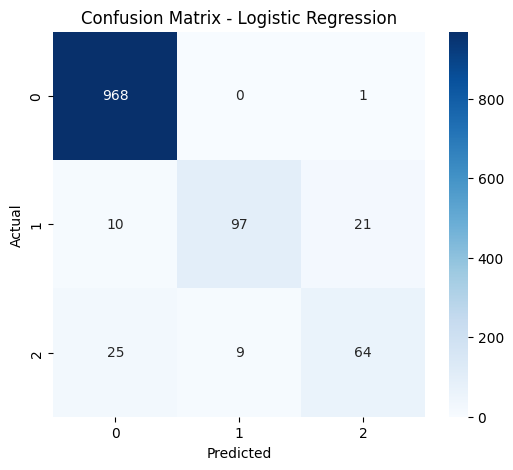


Training Naive Bayes...
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       969
           1       0.88      0.73      0.80       128
           2       0.70      0.66      0.68        98

    accuracy                           0.94      1195
   macro avg       0.85      0.80      0.82      1195
weighted avg       0.94      0.94      0.94      1195



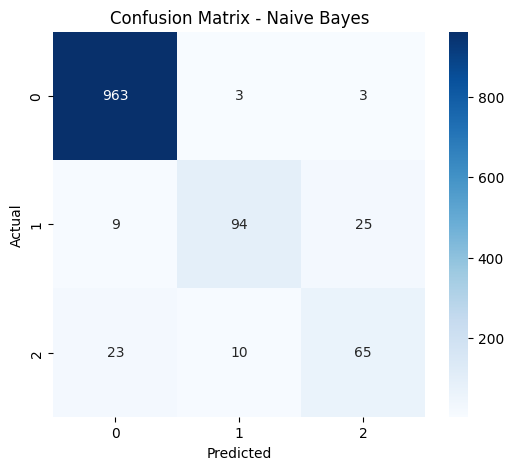


Training SVM...
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       969
           1       0.91      0.79      0.85       128
           2       0.78      0.71      0.74        98

    accuracy                           0.95      1195
   macro avg       0.89      0.83      0.86      1195
weighted avg       0.95      0.95      0.95      1195



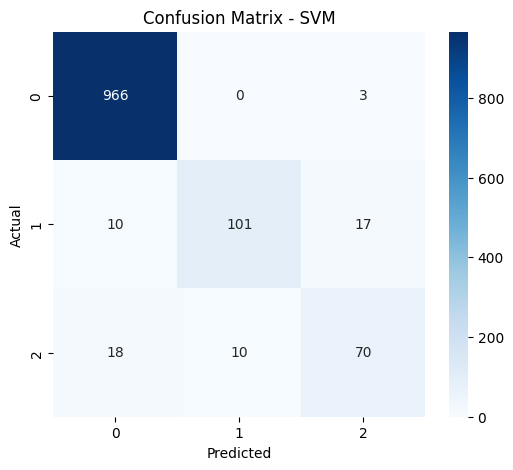


Training Random Forest...
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       969
           1       0.86      0.79      0.82       128
           2       0.72      0.71      0.72        98

    accuracy                           0.94      1195
   macro avg       0.85      0.83      0.84      1195
weighted avg       0.94      0.94      0.94      1195



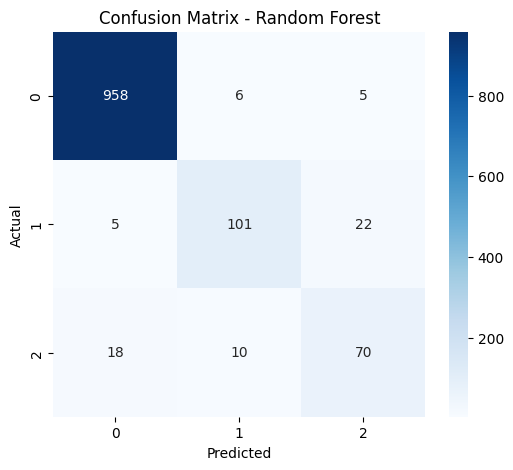


Training XGBoost...
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       969
           1       0.85      0.78      0.82       128
           2       0.70      0.66      0.68        98

    accuracy                           0.94      1195
   macro avg       0.84      0.81      0.83      1195
weighted avg       0.94      0.94      0.94      1195



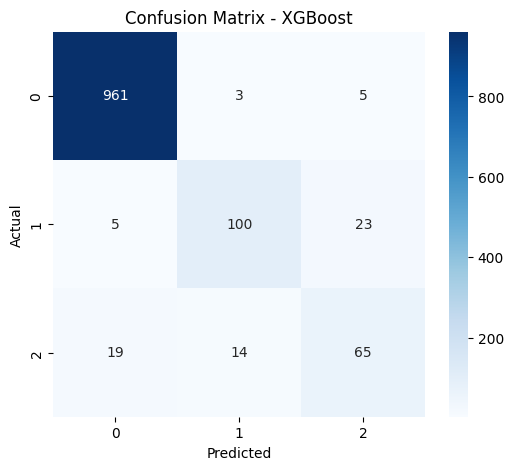

In [ ]:
results = []

for name, model in models.items():

    print(f'\nTraining {name}...')

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

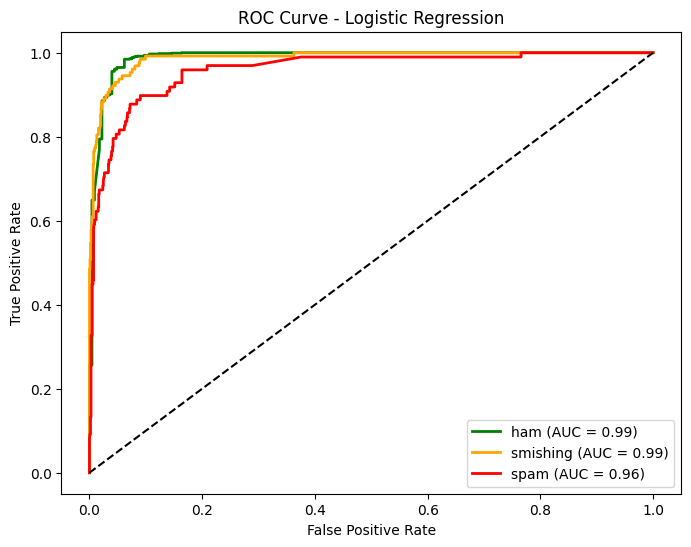

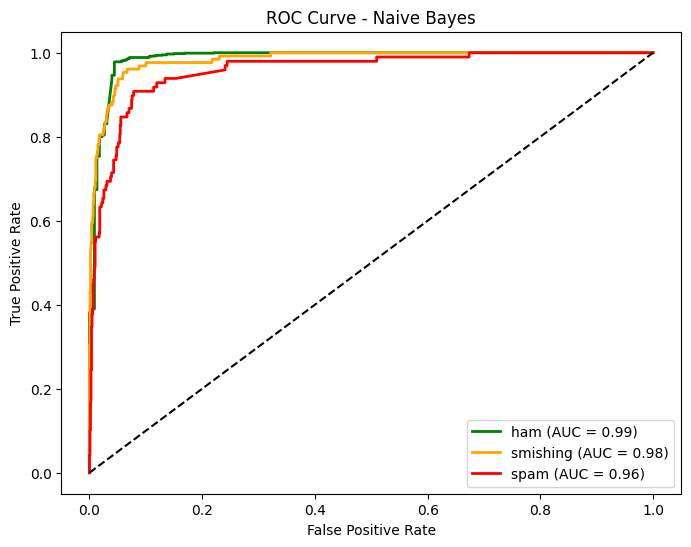

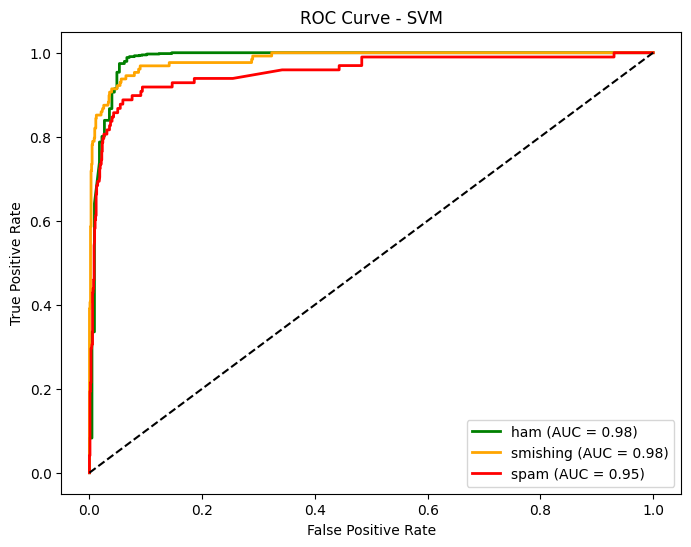

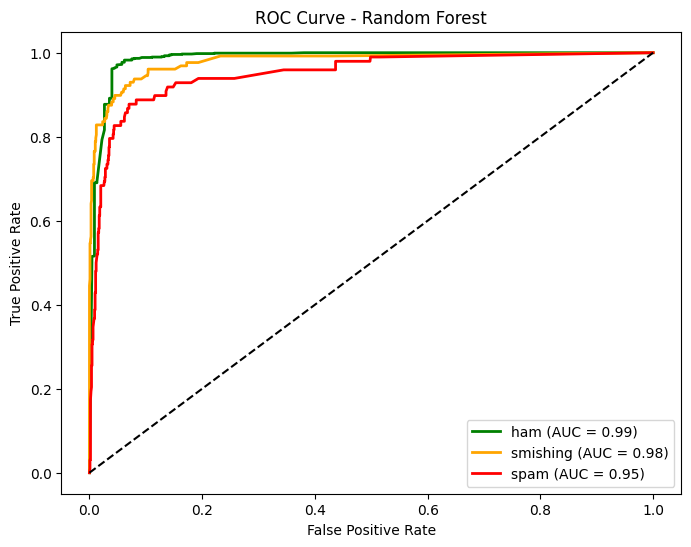

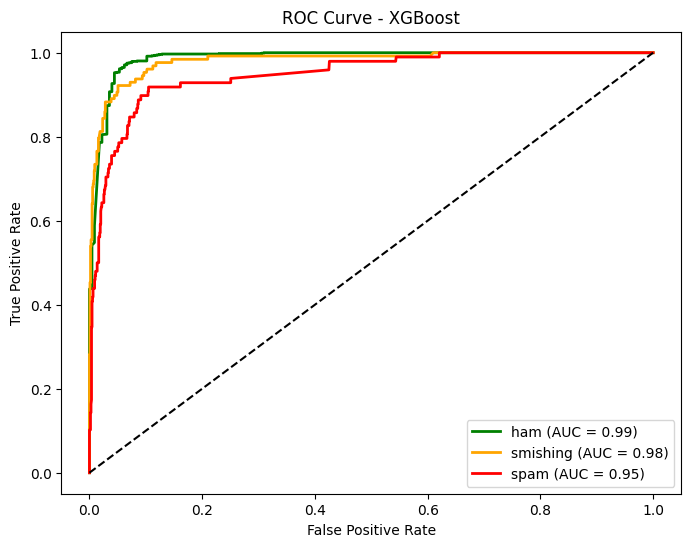

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Class names
class_names = ['ham', 'smishing', 'spam']

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Colors
colors = ['green', 'orange', 'red']

# Loop through models
for name, model in models.items():

    # Predict probabilities
    y_prob = model.predict_proba(X_test)

    # Create new figure for each model
    plt.figure(figsize=(8,6))

    # ROC for each class
    for i in range(3):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            color=colors[i],
            linewidth=2,
            label=f'{class_names[i]} (AUC = {roc_auc:.2f})'
        )

    # Random baseline
    plt.plot([0,1],[0,1],'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.title(f'ROC Curve - {name}')

    plt.legend()

    plt.show()

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1 Score']
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.944770   0.941631  0.944770  0.941928
1          Naive Bayes  0.938912   0.936217  0.938912  0.936697
2                  SVM  0.951464   0.949284  0.951464  0.949674
3        Random Forest  0.944770   0.943514  0.944770  0.943932
4              XGBoost  0.942259   0.939988  0.942259  0.940856


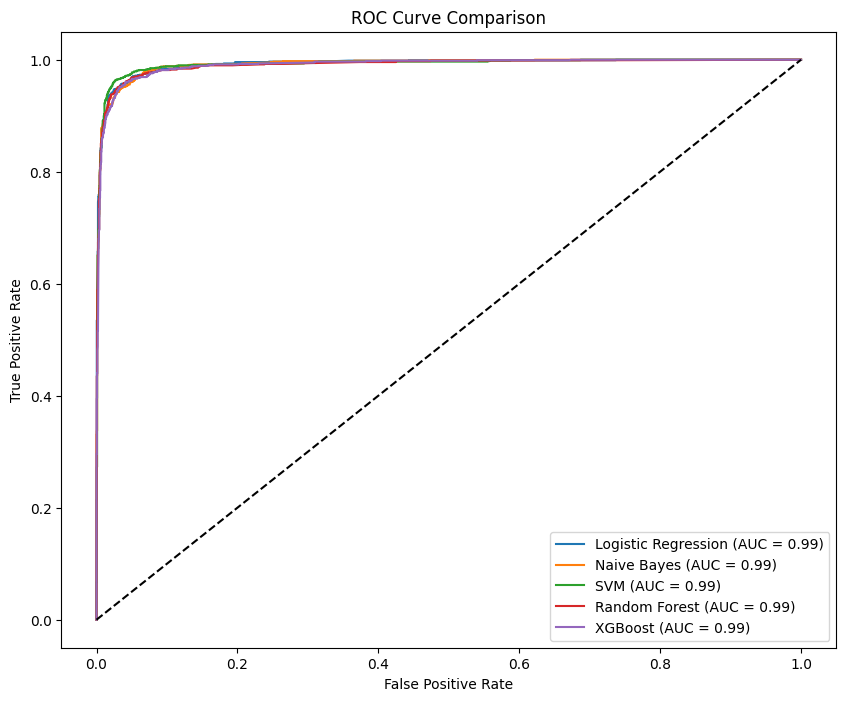

In [ ]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10,8))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.2f})'
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

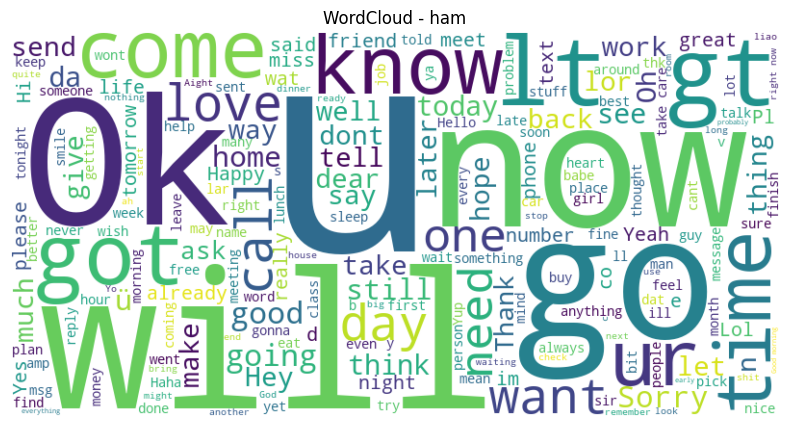

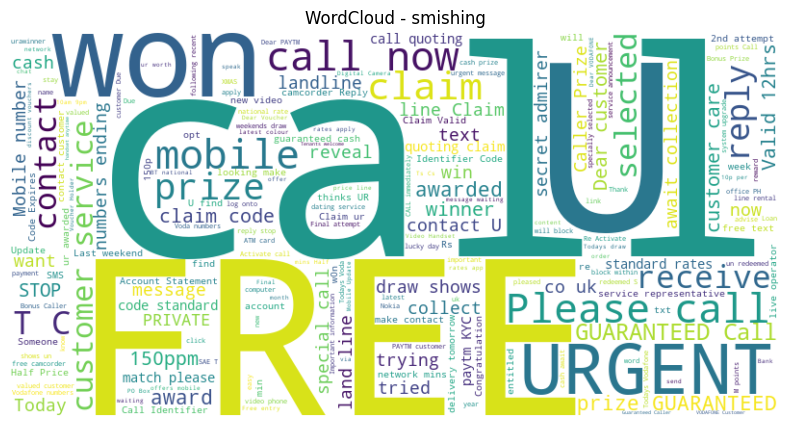

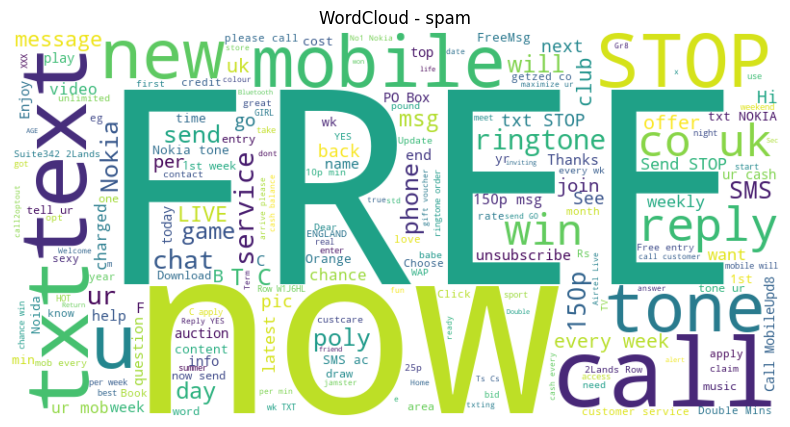

In [ ]:
for label in df['LABEL'].unique():

    text = ' '.join(df[df['LABEL']==label]['TEXT'].astype(str))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - {label}')
    plt.show()

      Feature  Importance
46      claim    0.072830
59   customer    0.048492
195     prize    0.035689
261       txt    0.033987
129  landline    0.026996
54    contact    0.022621
292       www    0.022537
119      http    0.020320
23    awarded    0.018041
265    urgent    0.017498
165    mobile    0.017027
87       free    0.015796
5        150p    0.014877
206     reply    0.013915
65   delivery    0.013736
57       cost    0.011182
12        500    0.011149
232      stop    0.011103
42       cash    0.010623
208  ringtone    0.010603


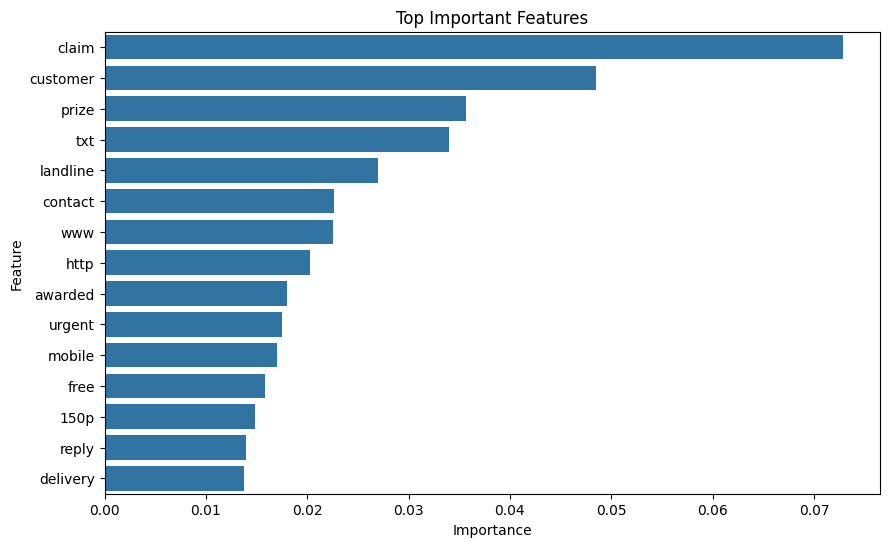

In [ ]:
xgb_model = models['XGBoost']

feature_names = list(vectorizer.get_feature_names_out()) + binary_cols

importance = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

print(feat_df.head(20))
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_df.head(15)
)

plt.title('Top Important Features')
plt.show()

In [ ]:
import shap
import numpy as np

# Get trained XGBoost model
xgb_model = models['XGBoost']

# Dense sample
X_sample = X_test[:20].toarray()

# Feature names
feature_names = list(vectorizer.get_feature_names_out()) + binary_cols

# SHAP explainer
explainer = shap.Explainer(
    xgb_model,
    X_sample,
    feature_names=feature_names
)

# SHAP values
shap_values = explainer(X_sample)

In [ ]:
print(np.array(shap_values.values).shape)


(20, 303, 3)


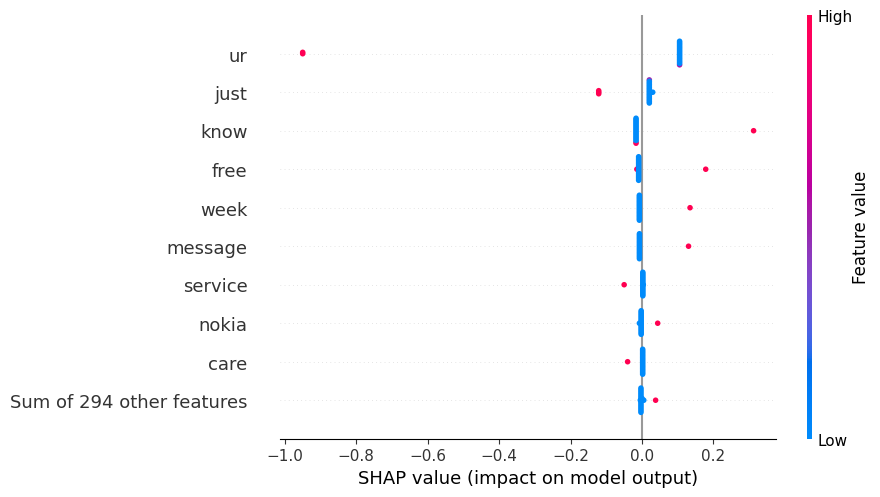

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

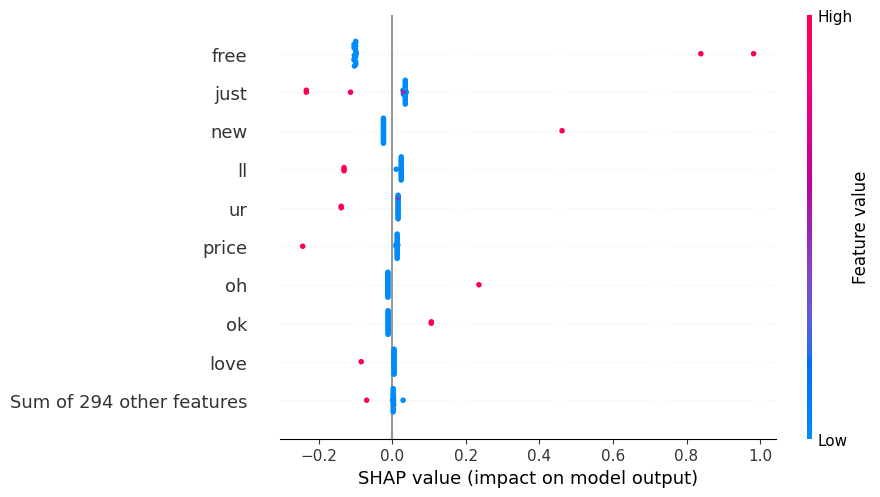

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 0])

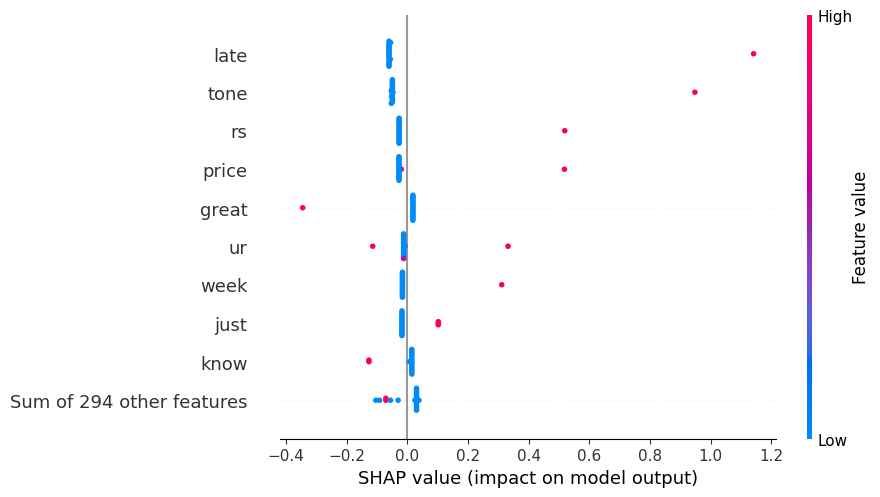

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 2])

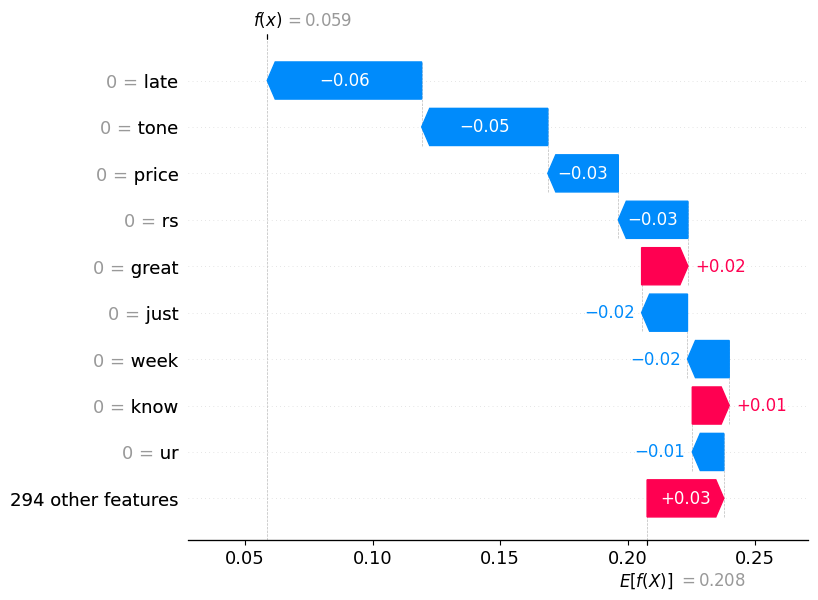

In [ ]:
shap.plots.waterfall(
    shap_values[3, :, 2]
)

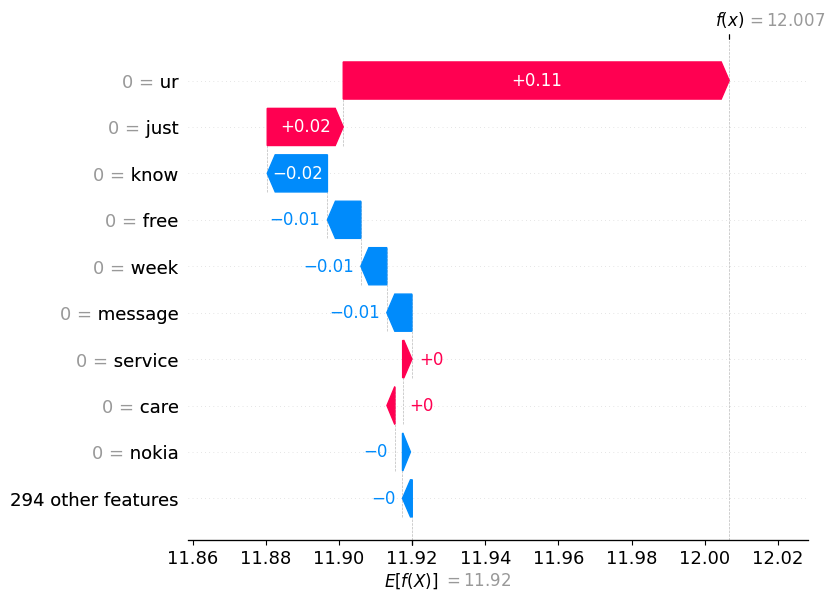

In [ ]:
shap.plots.waterfall(
    shap_values[3, :, 1]
)

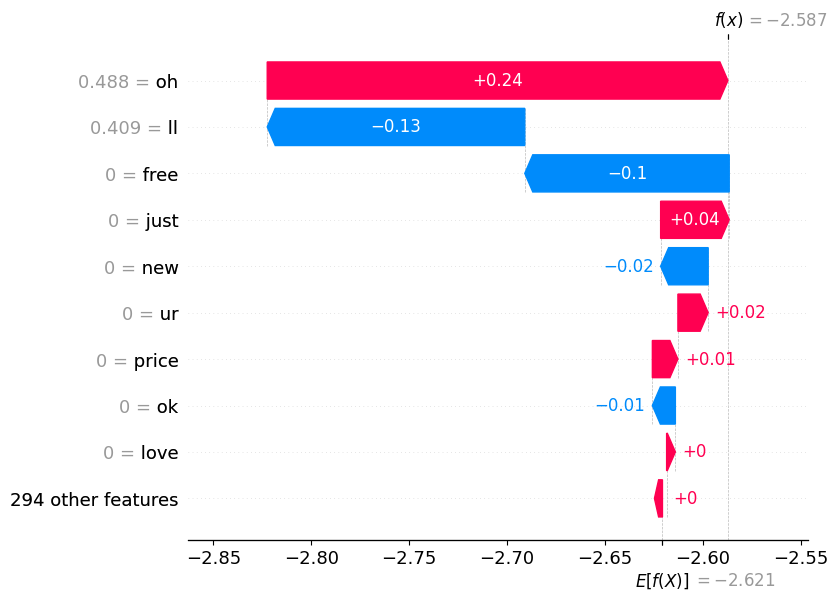

In [ ]:
shap.plots.waterfall(
    shap_values[3, :, 0]
)